## 量子线路编译演示 (Compilation Demo)
本示例展示如何使用 HYQ-ALG-LIB 将高层量子线路（包含复杂门如 MCX）编译分解为基础量子门（如 U3, CX）。

### 导入必要的库

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from backends.core import QuantumCircuit
from backends.Tensorcircuit import TensorCircuitBackend

Please first ``pip install -U qiskit`` to enable related functionality in translation module


### 构建高层量子线路
首先，我们构建一个包含 5 个量子比特的线路。为了测试编译器的能力，我们特意添加了一个多控制门（MCX，即带有4个控制位的非门）以及一些可以被合并的冗余门。

In [2]:
# 初始化 5 量子比特线路
n_qubits = 5
qc = QuantumCircuit(n_qubits, name="Grover_Oracle_Complex")

# 1. 叠加态制备 (Hadamard Layer)
qc.h(range(n_qubits))

# 2. 添加复杂的 MCX 门 (控制位: 0,1,2,3 -> 目标位: 4)
# 这是一个高层门，物理硬件通常不支持，需要编译分解
qc.mcx(controls=[0, 1, 2, 3], target=4)

# 3. 添加冗余门 (连续两个 H 门相当于单位矩阵 I，编译器应能识别并优化消除)
qc.h(4)
qc.h(4)

# 4. 添加单比特旋转门
qc.rx(0, np.pi/3)

<Instruction: Gate(name='RX'), qubits=[0], params=['1.047']>

### 指定后端

In [3]:
backend = TensorCircuitBackend()

### 可视化原始线路
在编译之前，我们先查看设计的高层逻辑电路图。

In [4]:
import matplotlib.pyplot as plt
print("[Visual] Original Circuit Diagram:")
print(backend.compiler.draw(qc, output="text",fold=-1))

[Visual] Original Circuit Diagram:
     ┌───┐     ┌─────────┐     
q_0: ┤ H ├──■──┤ Rx(π/3) ├─────
     ├───┤  │  └─────────┘     
q_1: ┤ H ├──■──────────────────
     ├───┤  │                  
q_2: ┤ H ├──■──────────────────
     ├───┤  │                  
q_3: ┤ H ├──■──────────────────
     ├───┤┌─┴─┐   ┌───┐   ┌───┐
q_4: ┤ H ├┤ X ├───┤ H ├───┤ H ├
     └───┘└───┘   └───┘   └───┘


也可以调用matplotlib模块生成彩色电路图，只需将output设置为 'mpl' 格式即可。  

[Visual] Original Circuit Diagram:


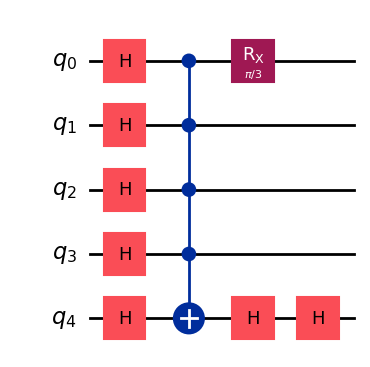

In [5]:
import matplotlib.pyplot as plt
print("[Visual] Original Circuit Diagram:")

backend.compiler.draw(qc,output='mpl')

### 查看电路信息
使用后端内置的compiler工具包查看电路信息，包括 量子比特数 $n$ ,量子门种类及个数, 线路深度等

In [6]:
backend.compiler.info(qc)

{'n_qubits': 5,
 'n_instructions': 9,
 'gate_counts': Counter({'H': 7, 'MCX': 1, 'RX': 1}),
 'multi_qubit_gates': 1,
 'depth_approx': 4,
 'parameterized': True}

### 执行线路转译
使用后端内置的compiler工具包中的 **transpile** 执行线路转译，将原始线路转译为后端支持的基门集合。  
我们将线路转译到目标基组 ['u3', 'cx']。  
Basis Gates: 目标量子硬件支持的门集合。  
Optimization Level: 设置为 3（最高级），编译器将尝试合并冗余门（例如消除之前的 H-H 对）并优化交换门排列。

In [7]:
compiled = backend.compiler.transpile(
    qc,
    basis_gates=["u3", "cx"],   #此处选择转译的基门集合为 u3 门和 cnot 门
    optimization_level=3,
)

compiled

<QuantumCircuit: qubits=5, instructions=80>

### 查看转译后的线路信息

In [8]:
backend.compiler.info(compiled)

{'n_qubits': 5,
 'n_instructions': 80,
 'gate_counts': Counter({'u3': 44, 'x': 36}),
 'multi_qubit_gates': 36,
 'depth_approx': 65,
 'parameterized': True}

### 可视化转译后的线路

In [9]:
print(backend.compiler.draw(compiled, output="text", fold=-1))

      ┌─────────────┐                                                                                                                                                                                                                                                                                                                             ┌──────────────┐                                                                                                                                                                                                                                                                                                                                                            ┌──────────────────┐                                                
q_0: ─┤ U3(π/2,0,π) ├───────────────────────────────────────────────────────────────────────■────────────────────────────────────────■───────────────────────────────────────────────────────────────────────────────────────────────

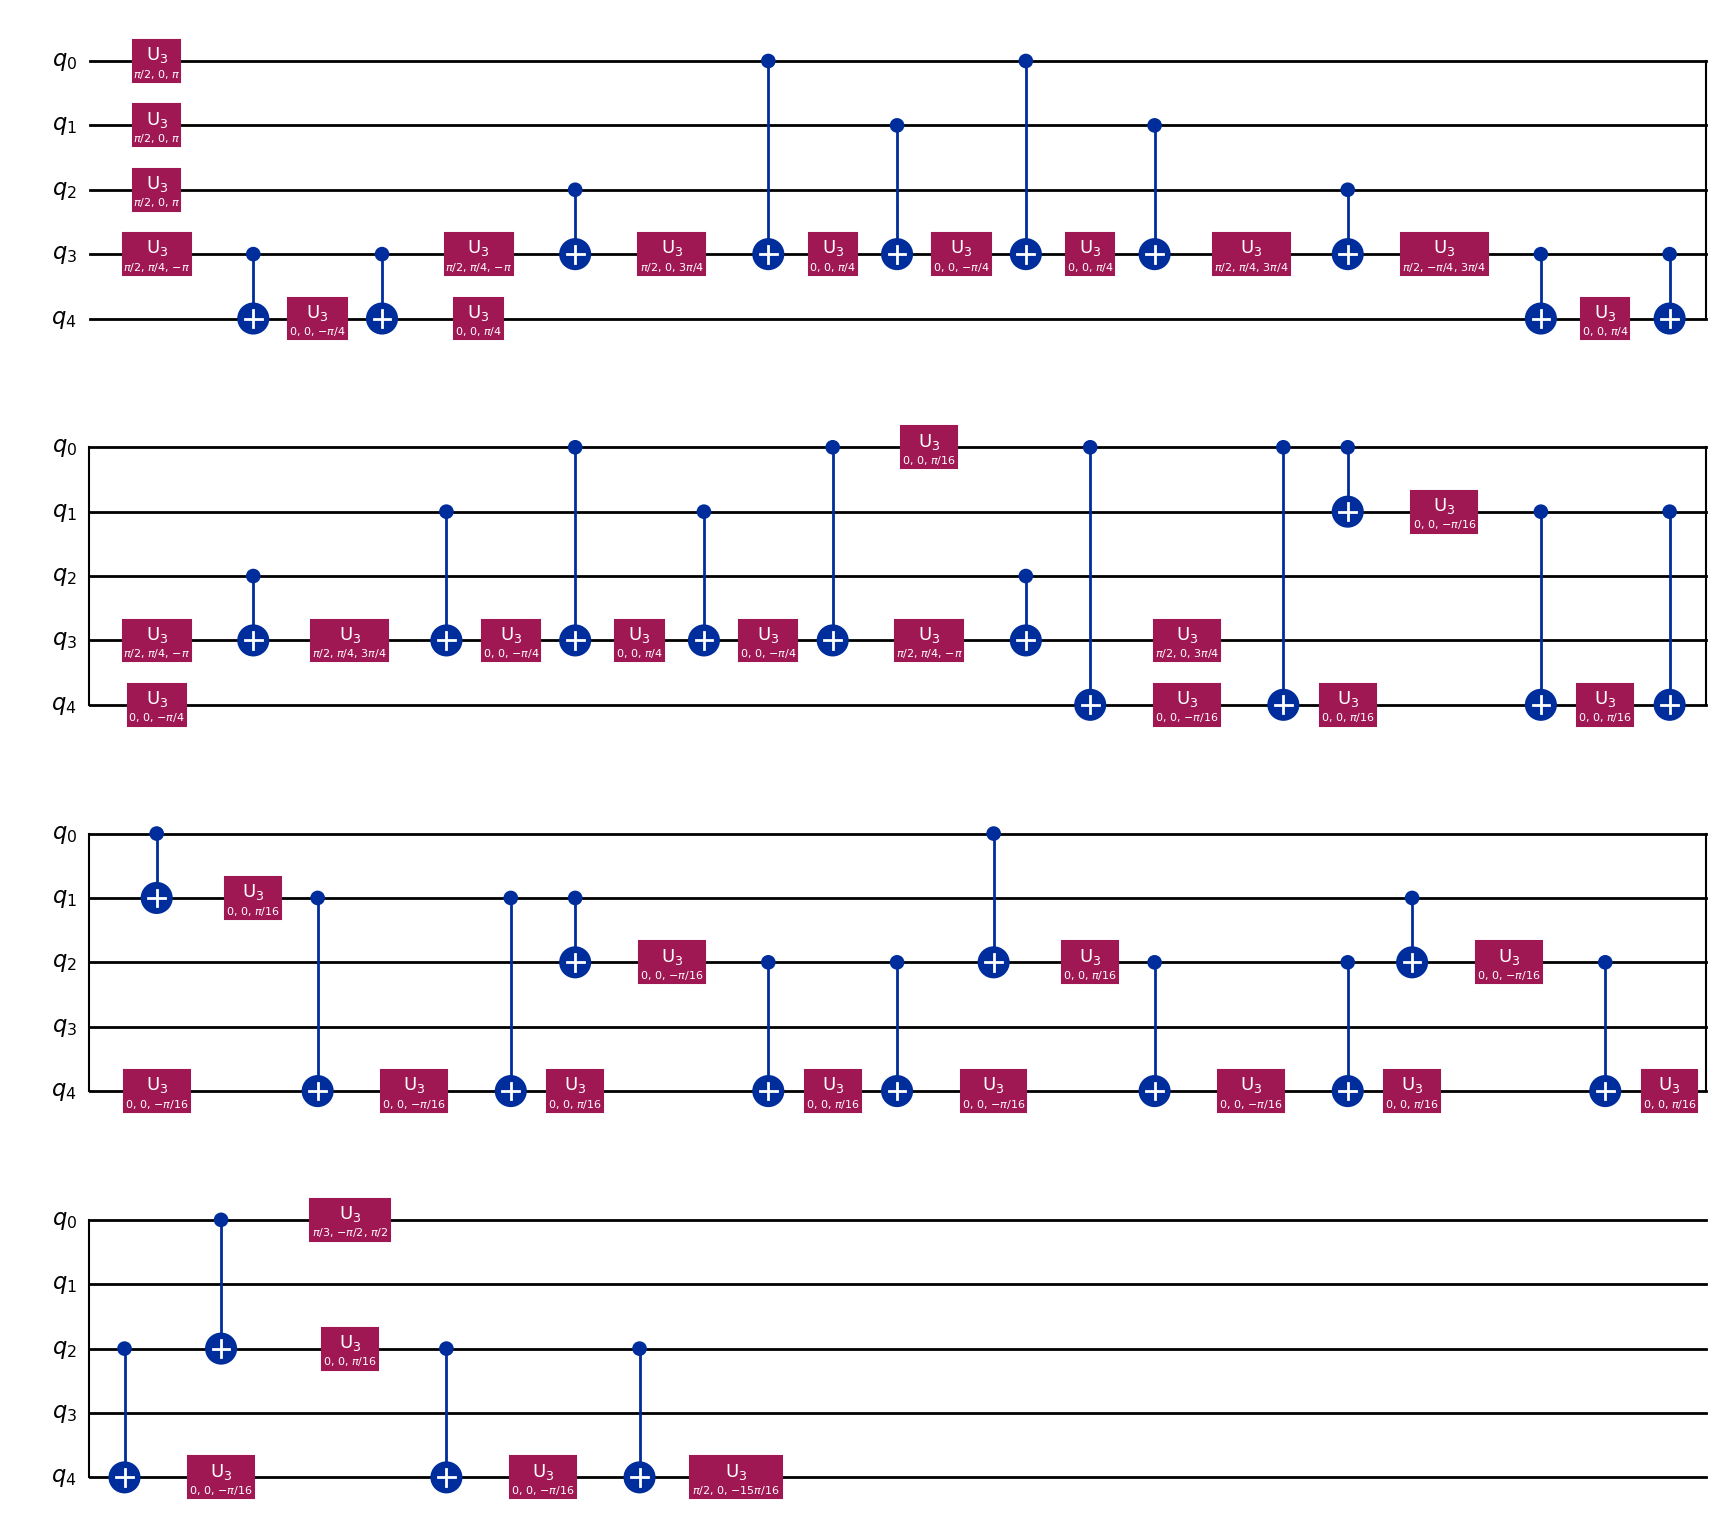

In [10]:
backend.compiler.draw(compiled, output="mpl")

### 编译结果分析
1. 译后线路图  
由上图可以看到 MCX 门被分解为了一系列 U3 和 CNOT (CX) 门。同时，原始线路末尾的冗余 H 门应该已被优化移除。

2. 深度与门数量统计  
对比编译前后的线路深度（Depth）和门数量，评估编译带来的硬件开销。

In [11]:
stats_orig = qc.stats()
stats_compiled = compiled.stats()

print("\n[Stats Comparison]")
print(f"Original Depth: {stats_orig['depth_approx']} | Gates: {dict(stats_orig['gate_counts'])}")
print(f"Compiled Depth: {stats_compiled['depth_approx']} | Gates: {dict(stats_compiled['gate_counts'])}")


[Stats Comparison]
Original Depth: 4 | Gates: {'H': 7, 'MCX': 1, 'RX': 1}
Compiled Depth: 65 | Gates: {'u3': 44, 'x': 36}


3. 可视化对比图表  
生成柱状图直观对比门分解前后的指令数变化。

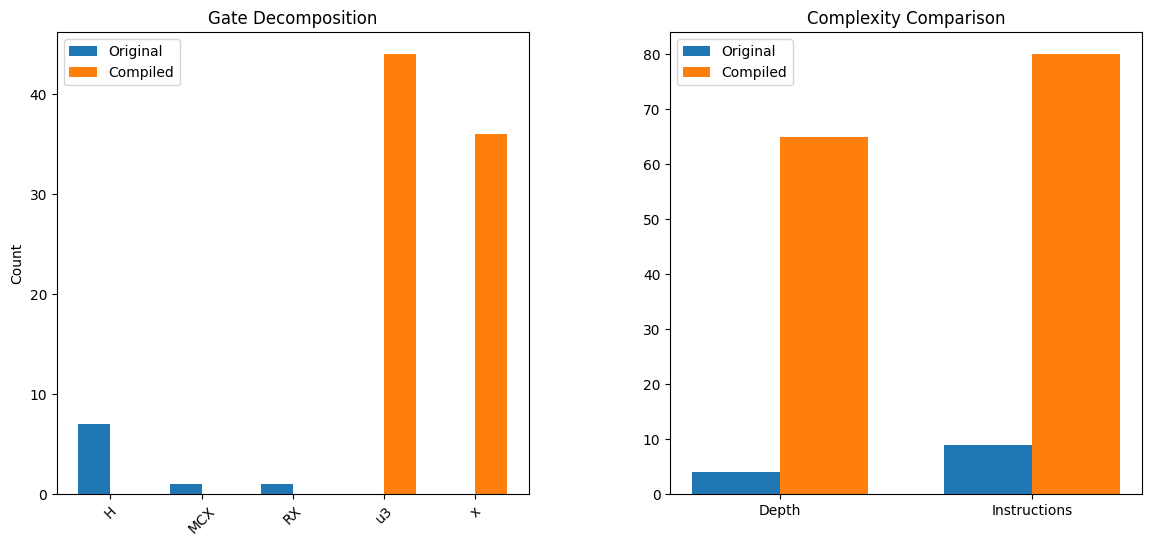

In [12]:
# 设置绘图数据
gates_orig = stats_orig['gate_counts']
gates_comp = stats_compiled['gate_counts']
all_gates = sorted(list(set(gates_orig.keys()) | set(gates_comp.keys())))

x = np.arange(len(all_gates))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
plt.subplots_adjust(wspace=0.3)

# 图1：门类型分解情况
ax1.bar(x - width/2, [gates_orig.get(g, 0) for g in all_gates], width, label='Original')
ax1.bar(x + width/2, [gates_comp.get(g, 0) for g in all_gates], width, label='Compiled')
ax1.set_ylabel('Count')
ax1.set_title('Gate Decomposition')
ax1.set_xticks(x)
ax1.set_xticklabels(all_gates, rotation=45)
ax1.legend()

# 图2：总体复杂度对比
metrics = ['Depth', 'Instructions']
vals_orig = [stats_orig['depth_approx'], stats_orig['n_instructions']]
vals_comp = [stats_compiled['depth_approx'], stats_compiled['n_instructions']]

x_m = np.arange(len(metrics))
ax2.bar(x_m - width/2, vals_orig, width, label='Original')
ax2.bar(x_m + width/2, vals_comp, width, label='Compiled')
ax2.set_title('Complexity Comparison')
ax2.set_xticks(x_m)
ax2.set_xticklabels(metrics)
ax2.legend()

plt.show()